### Подготовка окружения

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

from thinkdsp import decorate, read_wave, Wave

## Упражнение 10.1

В разделе 10.4 свёртка описывается как сумма сдвинутых масштабированных копий сигнала. Строго говоря, это *линейная* свёртка, которая не предполагает периодичности сигнала.

Однако в разделе 10.3, когда мы умножаем ДПФ сигнала на передаточную функцию, эта операция соответствует *циклической* свёртке, которая предполагает периодичность сигнала. В результате на выходе может появиться лишняя нота в начале, «завернувшаяся» с конца.

Стандартное решение: добавить достаточно нулей в конец сигнала перед вычислением ДПФ, чтобы избежать заворачивания и получить линейную свёртку.

Продемонстрируем это на примере.

### Загрузка импульсной характеристики

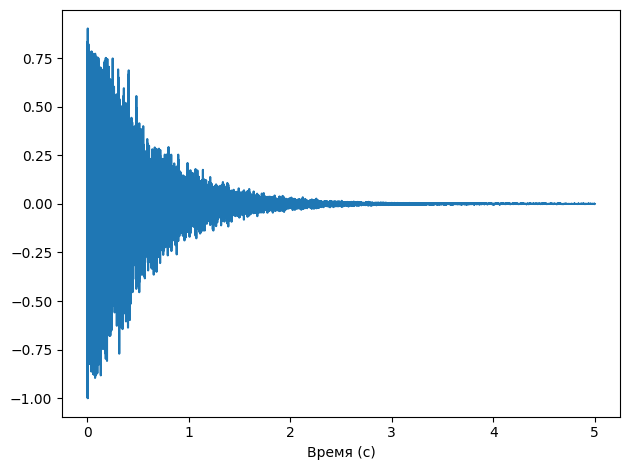

In [17]:
response = read_wave(str(current_path / '1a_marble_hall.wav'))

start = 0.0
response = response.segment(duration=5.0)
response.shift(-start)
response.normalize()
response.plot()
decorate(xlabel='Время (с)')

### Загрузка сигнала (труба)

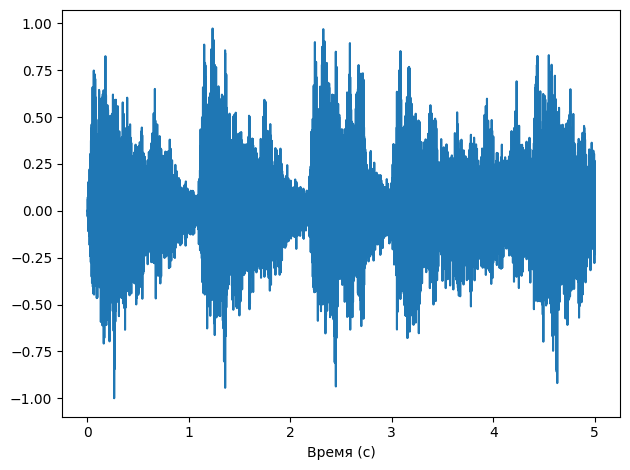

In [18]:
wave = read_wave(str(current_path / '170255__dublie__trumpet.wav'))

start = 0.0
wave = wave.segment(duration=5.0)
wave.shift(-start)
wave.normalize()
wave.plot()
decorate(xlabel='Время (с)')

### Усечение и дополнение нулями

Чтобы избежать циклической свёртки, усечём оба сигнала до степени двойки ($2^{16}$), а затем дополним нулями до $2^{17}$.

In [19]:
N = 2**16
M = 2**17

response.truncate(N)
response.zero_pad(M)
response.normalize()

wave.truncate(N)
wave.zero_pad(M)
wave.normalize()

### Вычисление передаточной функции и ДПФ сигнала

In [20]:
transfer = response.make_spectrum()
spectrum = wave.make_spectrum()

### Умножение в частотной области и обратное преобразование

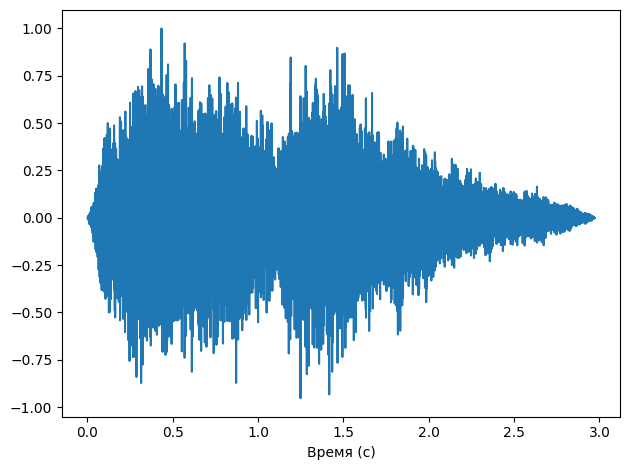

In [21]:
output = (spectrum * transfer).make_wave()
output.normalize()

output.plot()
decorate(xlabel='Время (с)')

На графике видно, что лишняя нота в начале отсутствует — заворачивания не произошло благодаря дополнению нулями.

In [22]:
output.make_audio()

Сравним с результатом `np.convolve` (линейная свёртка):

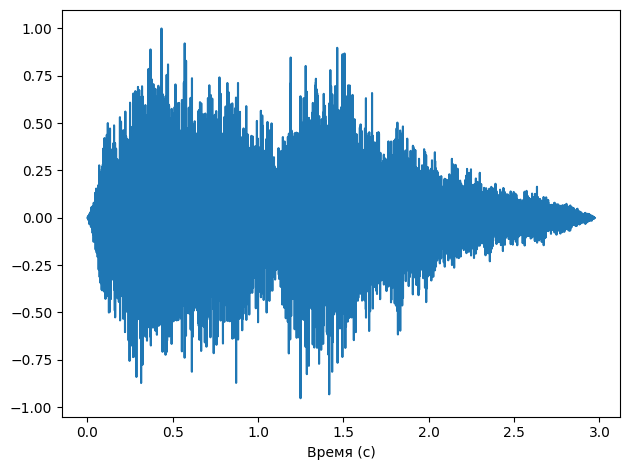

In [23]:
response.truncate(N)
wave.truncate(N)

convolved = wave.convolve(response)
convolved.normalize()

convolved.plot()
decorate(xlabel='Время (с)')

In [24]:
convolved.make_audio()

Результаты совпадают (с точностью до вычислительной погрешности), что подтверждает: дополнение нулями превращает циклическую свёртку в линейную.

## Упражнение 10.2

В данном упражнении используется файл `1a_marble_hall.wav` (импульсная характеристика мраморного зала, Open AIR) и запись трубы. Сымитируем звучание трубы в этом помещении двумя способами:
- **A:** свёртка сигнала с импульсной характеристикой;
- **B:** вычисление фильтра (передаточной функции) из импульсной характеристики и умножение на ДПФ сигнала.

### Перезагрузим файлы без усечения

In [11]:
response2 = read_wave(str(current_path / '1a_marble_hall.wav'))
response2 = response2.segment(duration=2.0)
response2.normalize()

wave2 = read_wave(str(current_path / '170255__dublie__trumpet.wav'))
wave2 = wave2.segment(duration=2.0)
wave2.normalize()

### Метод A: свёртка (linear convolution)

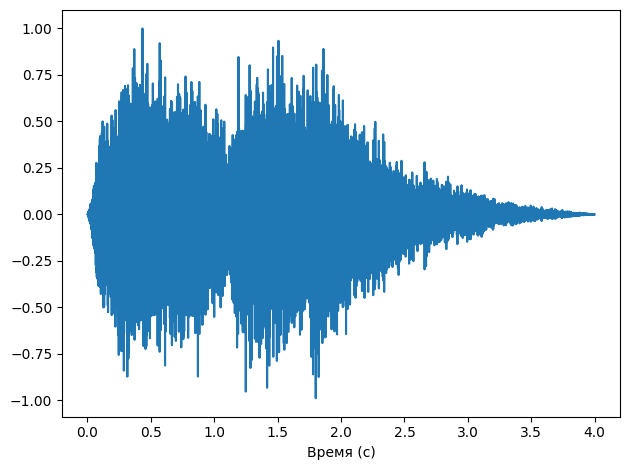

In [12]:
convolved_a = wave2.convolve(response2)
convolved_a.normalize()

convolved_a.plot()
decorate(xlabel='Время (с)')

In [13]:
convolved_a.make_audio()

### Метод B: ДПФ-умножение с дополнением нулями

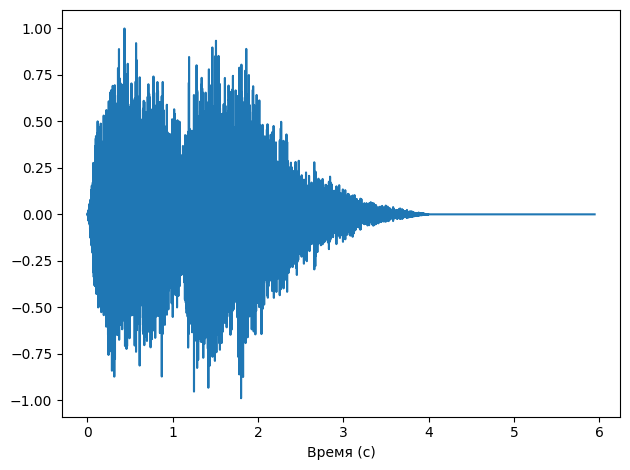

In [14]:
n = len(wave2.ys) + len(response2.ys)
n = 1 << (n - 1).bit_length()  # ближайшая степень двойки

wave_padded = wave2.copy()
wave_padded.zero_pad(n)

resp_padded = response2.copy()
resp_padded.zero_pad(n)

transfer_b = resp_padded.make_spectrum()
spectrum_b = wave_padded.make_spectrum()

convolved_b = (spectrum_b * transfer_b).make_wave()
convolved_b.normalize()

convolved_b.plot()
decorate(xlabel='Время (с)')

In [15]:
convolved_b.make_audio()

### Сравнение методов

Усечём результат ДПФ-метода до длины линейной свёртки и сравним.

In [16]:
from thinkdsp import truncate

convolved_b.ys = truncate(convolved_b.ys, len(convolved_a.ys))
convolved_b.ts = convolved_b.ts[:len(convolved_a.ys)]

max_diff = convolved_a.max_diff(convolved_b)
print(f'Максимальная разница между методами: {max_diff:.2e}')

Максимальная разница между методами: 5.55e-16


Оба метода дают одинаковый результат (с точностью до вычислительной погрешности). Это подтверждает, что умножение ДПФ сигнала на передаточную функцию эквивалентно свёртке во временной области (при условии правильного дополнения нулями).